             STAGE 1: DATA INGESTION SUMMARY                
<class 'pandas.DataFrame'>
RangeIndex: 2304 entries, 0 to 2303
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Product_name  2304 non-null   str  
 1   Review        2304 non-null   str  
 2   Rating        2304 non-null   int64
dtypes: int64(1), str(2)
memory usage: 54.1 KB
None


         ANALYSIS 1: MACRO SENTIMENT DISTRIBUTION           
Sentiment
Positive    1555
Neutral      562
Negative     187
Name: count, dtype: int64
Total Processed Reviews: 2304

    ANALYSIS 2: MICRO-LEVEL PRODUCT SATISFACTION (LOWEST 5)  
Product: realme C21Y (Cross Black, 32 GB)  (3 GB RAM)...
   ↳ Avg Rating: 3.1 ★ | Avg Polarity: -0.3933 | Reviews Checked: 20

Product: realme C21Y (Cross Blue, 32 GB)  (3 GB RAM)...
   ↳ Avg Rating: 3.1 ★ | Avg Polarity: -0.3933 | Reviews Checked: 20

Product: Redmi 9A (Sea Blue, 32 GB)  (3 GB RAM)...
   ↳ Avg Rating: 3.1 ★ | Avg Polarity: -

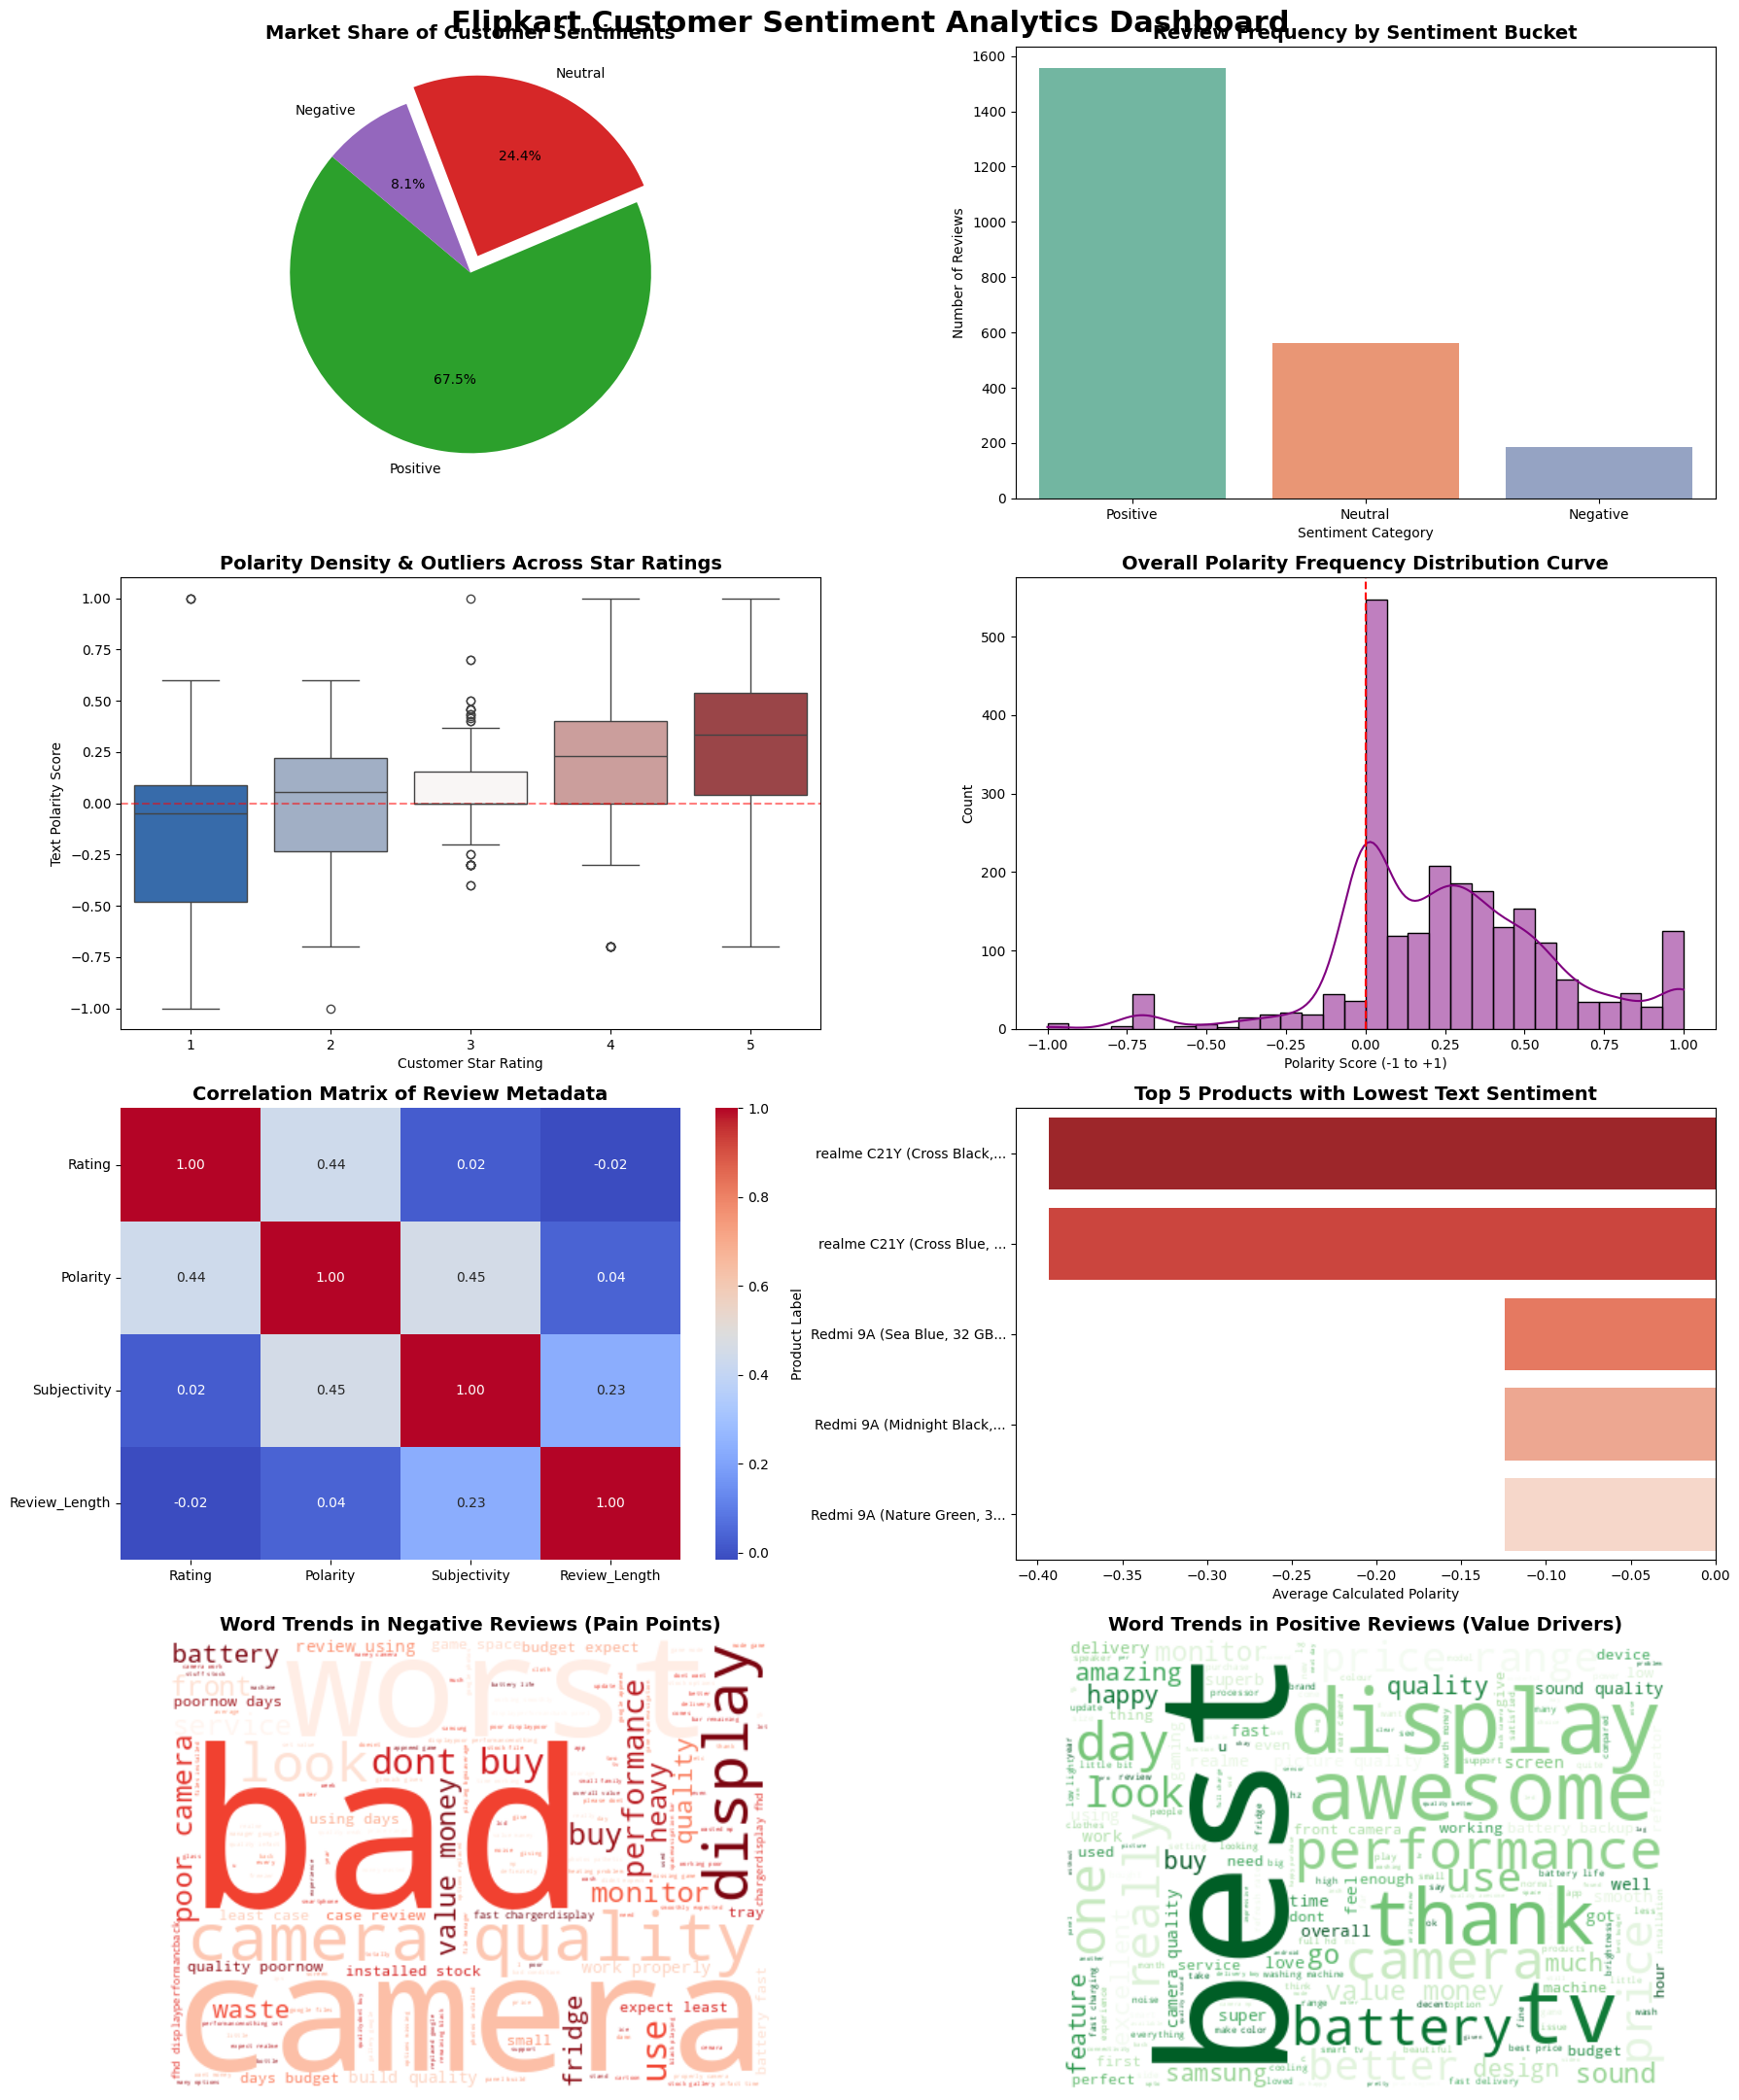


Pipeline complete. Log output stored as 'flipkart_comprehensive_sentiment_analytics.csv'.


In [4]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob
import nltk
from nltk.corpus import stopwords
from wordcloud import WordCloud

# ---------------------------------------------------------------------
# SETUP LOCAL CORPORA
# ---------------------------------------------------------------------
nltk.download('stopwords', quiet=True)
stop_words = set(stopwords.words('english'))
stop_words.update(['laptop', 'flipkart', 'product', 'good', 'nice', 'great', 'phone', 'mobile', 'product'])

# ---------------------------------------------------------------------
# 1. DATA INGESTION & STAGE 1 LOGGING
# ---------------------------------------------------------------------
df = pd.read_csv('flipkart.csv')
df = df.drop(columns=['Unnamed: 0'], errors='ignore')  
df = df.dropna(subset=['Review', 'Rating'])

# Exact structural logging matching your preferred format
print("============================================================")
print("             STAGE 1: DATA INGESTION SUMMARY                ")
print("============================================================")
print(df.info())
print("\n")

# ---------------------------------------------------------------------
# 2. NLP TEXT PREPROCESSING
# ---------------------------------------------------------------------
def deep_clean(text):
    if not isinstance(text, str): 
        return ""
    text = text.lower()
    text = re.sub(r'<.*?>|[^a-zA-Z\s]', '', text)
    return " ".join([w for w in text.split() if w not in stop_words])

df['Cleaned_Review'] = df['Review'].apply(deep_clean)

# Calculate calculated text parameters
df['Polarity'] = df['Cleaned_Review'].apply(lambda x: TextBlob(x).sentiment.polarity)
df['Subjectivity'] = df['Cleaned_Review'].apply(lambda x: TextBlob(x).sentiment.subjectivity)
df['Review_Length'] = df['Review'].apply(lambda x: len(str(x)))

def classify_sentiment(score):
    if score > 0.05: return 'Positive'
    elif score < -0.05: return 'Negative'
    else: return 'Neutral'

df['Sentiment'] = df['Polarity'].apply(classify_sentiment)

# ---------------------------------------------------------------------
# 3. CONSOLIDATED ANALYTICAL TERMINAL OUTPUT
# ---------------------------------------------------------------------
print("="*60)
print("         ANALYSIS 1: MACRO SENTIMENT DISTRIBUTION           ")
print("="*60)
print(df['Sentiment'].value_counts())
print(f"Total Processed Reviews: {len(df)}")

print("\n" + "="*60)
print("    ANALYSIS 2: MICRO-LEVEL PRODUCT SATISFACTION (LOWEST 5)  ")
print("="*60)

product_stats = df.groupby('Product_name').agg(
    Avg_Rating=('Rating', 'mean'),
    Avg_Polarity=('Polarity', 'mean'),
    Review_Count=('Review', 'count')
).reset_index()

lowest_satisfaction = product_stats[product_stats['Review_Count'] >= 5].sort_values(by='Avg_Polarity').head(5).copy()
lowest_satisfaction['Avg_Rating'] = lowest_satisfaction['Avg_Rating'].round(2)
lowest_satisfaction['Avg_Polarity'] = lowest_satisfaction['Avg_Polarity'].round(4)

for idx, row in lowest_satisfaction.iterrows():
    print(f"Product: {row['Product_name'][:65]}...")
    print(f"   ↳ Avg Rating: {row['Avg_Rating']} ★ | Avg Polarity: {row['Avg_Polarity']} | Reviews Checked: {row['Review_Count']}\n")
print("="*60)

# ---------------------------------------------------------------------
# 4. ADVANCED 8-PANE VISUALIZATION DASHBOARD
# ---------------------------------------------------------------------
fig, axes = plt.subplots(4, 2, figsize=(18, 22))
fig.suptitle('Flipkart Customer Sentiment Analytics Dashboard', fontsize=22, fontweight='bold', y=0.98)

# Chart 1: Share of Sentiment (Pie Chart)
sentiment_counts = df['Sentiment'].value_counts()
axes[0, 0].pie(sentiment_counts, labels=sentiment_counts.index, autopct='%1.1f%%', 
        colors=['#2ca02c', '#d62728', '#9467bd'], startangle=140, explode=(0, 0.1, 0))
axes[0, 0].set_title('Market Share of Customer Sentiments', fontsize=14, fontweight='bold')

# Chart 2: Volume Count of Sentiment (Bar Chart)
sns.countplot(data=df, x='Sentiment', hue='Sentiment', palette='Set2', 
              order=['Positive', 'Neutral', 'Negative'], ax=axes[0, 1], legend=False)
axes[0, 1].set_title('Review Frequency by Sentiment Bucket', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Sentiment Category')
axes[0, 1].set_ylabel('Number of Reviews')

# Chart 3: Polarity Spread across Star Ratings (Box Plot)
sns.boxplot(data=df, x='Rating', y='Polarity', hue='Rating', palette='vlag', ax=axes[1, 0], legend=False)
axes[1, 0].axhline(0, color='red', linestyle='--', alpha=0.5)
axes[1, 0].set_title('Polarity Density & Outliers Across Star Ratings', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Customer Star Rating')
axes[1, 0].set_ylabel('Text Polarity Score')

# Chart 4: Data Distribution Shape (Histogram Density Curve)
sns.histplot(data=df, x='Polarity', kde=True, color='purple', bins=30, ax=axes[1, 1])
axes[1, 1].axvline(0, color='red', linestyle='--')
axes[1, 1].set_title('Overall Polarity Frequency Distribution Curve', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Polarity Score (-1 to +1)')

# Chart 5: Feature Multi-Correlation (Heatmap Matrix)
corr_matrix = df[['Rating', 'Polarity', 'Subjectivity', 'Review_Length']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", ax=axes[2, 0], cbar=True)
axes[2, 0].set_title('Correlation Matrix of Review Metadata', fontsize=14, fontweight='bold')

# Chart 6: Product Ranking Matrix (Horizontal Bar Chart)
top_lowest_products = lowest_satisfaction.sort_values(by='Avg_Polarity', ascending=True)
top_lowest_products['Short_Name'] = top_lowest_products['Product_name'].apply(lambda x: x[:25] + "...")
sns.barplot(data=top_lowest_products, x='Avg_Polarity', y='Short_Name', hue='Short_Name', palette='Reds_r', ax=axes[2, 1], legend=False)
axes[2, 1].set_title('Top 5 Products with Lowest Text Sentiment', fontsize=14, fontweight='bold')
axes[2, 1].set_xlabel('Average Calculated Polarity')
axes[2, 1].set_ylabel('Product Label')

# Chart 7 & 8: Text Tokenization Analysis (Word Clouds)
negative_text = " ".join(df[df['Sentiment'] == 'Negative']['Cleaned_Review'])
positive_text = " ".join(df[df['Sentiment'] == 'Positive']['Cleaned_Review'])

if negative_text.strip():
    wordcloud_neg = WordCloud(width=400, height=300, background_color='white', colormap='Reds').generate(negative_text)
    axes[3, 0].imshow(wordcloud_neg, interpolation='bilinear')
axes[3, 0].set_title('Word Trends in Negative Reviews (Pain Points)', fontsize=14, fontweight='bold')
axes[3, 0].axis('off')

if positive_text.strip():
    wordcloud_pos = WordCloud(width=400, height=300, background_color='white', colormap='Greens').generate(positive_text)
    axes[3, 1].imshow(wordcloud_pos, interpolation='bilinear')
axes[3, 1].set_title('Word Trends in Positive Reviews (Value Drivers)', fontsize=14, fontweight='bold')
axes[3, 1].axis('off')

# Render configuration elements
plt.tight_layout()
print("\n[System Notice] Compiling and displaying expanded 8-pane dashboard panel...")
plt.show()

# ---------------------------------------------------------------------
# 5. EXPORT MASTER RECORDS
# ---------------------------------------------------------------------
df.to_csv('flipkart_comprehensive_sentiment_analytics.csv', index=False)
print("\nPipeline complete. Log output stored as 'flipkart_comprehensive_sentiment_analytics.csv'.")